# WEEK 3 - Cleaning Sprint

## Missing Value Handling and Outlier Detection

In this week, the dataset is cleaned by handling missing values and
detecting outliers.

Appropriate imputation techniques are applied without modifying the
original raw dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## Loading the Raw Dataset

The original dataset is loaded again and a separate copy is created
for data cleaning so that the raw dataset remains unchanged.

In [2]:
df = pd.read_csv("Dataset/social_media_vs_productivity.csv")

clean_df = df.copy()

print("Dataset loaded successfully!")
print("Cleaning copy created successfully!")

Dataset loaded successfully!
Cleaning copy created successfully!


In [3]:
print("Dataset shape:", clean_df.shape)
print("Total missing values:", clean_df.isnull().sum().sum())

Dataset shape: (30000, 19)
Total missing values: 16187


## Missing Value Treatment

Before filling missing values, the distribution of numerical attributes
is examined using skewness.

Mean imputation is suitable for approximately symmetric data, while
median imputation is more suitable for skewed data and data affected
by extreme values.

In [4]:
missing_columns = clean_df.columns[clean_df.isnull().any()]

print("Skewness of columns with missing values:\n")

for column in missing_columns:
    print(column, ":", round(clean_df[column].skew(), 2))

Skewness of columns with missing values:

daily_social_media_time : 1.19
perceived_productivity_score : -0.01
actual_productivity_score : -0.01
stress_level : 0.0
sleep_hours : 0.0
screen_time_before_sleep : 0.3
job_satisfaction_score : 0.01


## Applying Imputation

Based on the skewness analysis:

- Median imputation is used for `daily_social_media_time`
  because the distribution is positively skewed.
- Mean imputation is used for the remaining numerical attributes
  because their distributions are approximately symmetric.

In [5]:
clean_df["daily_social_media_time"] = clean_df["daily_social_media_time"].fillna(
    clean_df["daily_social_media_time"].median()
)

mean_columns = [
    "perceived_productivity_score",
    "actual_productivity_score",
    "stress_level",
    "sleep_hours",
    "screen_time_before_sleep",
    "job_satisfaction_score"
]

for column in mean_columns:
    clean_df[column] = clean_df[column].fillna(clean_df[column].mean())

print("Missing values handled successfully!")

Missing values handled successfully!


In [6]:
print("Missing values after imputation:\n")
print(clean_df.isnull().sum())

print("\nTotal missing values:", clean_df.isnull().sum().sum())

Missing values after imputation:

age                               0
gender                            0
job_type                          0
daily_social_media_time           0
social_platform_preference        0
number_of_notifications           0
work_hours_per_day                0
perceived_productivity_score      0
actual_productivity_score         0
stress_level                      0
sleep_hours                       0
screen_time_before_sleep          0
breaks_during_work                0
uses_focus_apps                   0
has_digital_wellbeing_enabled     0
coffee_consumption_per_day        0
days_feeling_burnout_per_month    0
weekly_offline_hours              0
job_satisfaction_score            0
dtype: int64

Total missing values: 0


### Observation

All missing values were successfully handled using suitable imputation
methods. The cleaned dataset now contains no missing values.

## Outlier Detection

Outliers are extreme values that are significantly different from the
majority of observations.

Boxplots are used to visually identify possible outliers in numerical
attributes before deciding whether they should be treated.

In [7]:
numeric_columns = clean_df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical columns:")
print(list(numeric_columns))

Numerical columns:
['age', 'daily_social_media_time', 'number_of_notifications', 'work_hours_per_day', 'perceived_productivity_score', 'actual_productivity_score', 'stress_level', 'sleep_hours', 'screen_time_before_sleep', 'breaks_during_work', 'coffee_consumption_per_day', 'days_feeling_burnout_per_month', 'weekly_offline_hours', 'job_satisfaction_score']


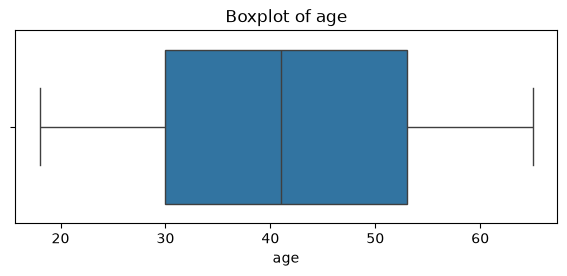

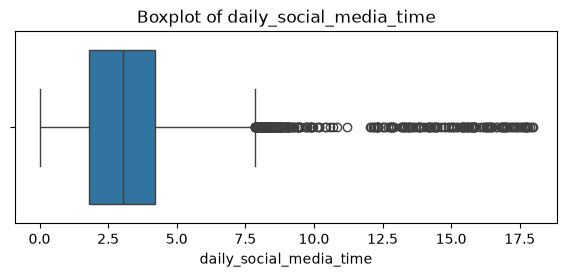

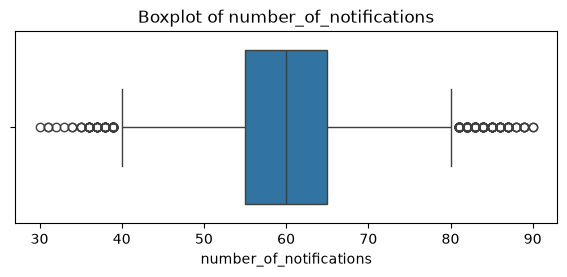

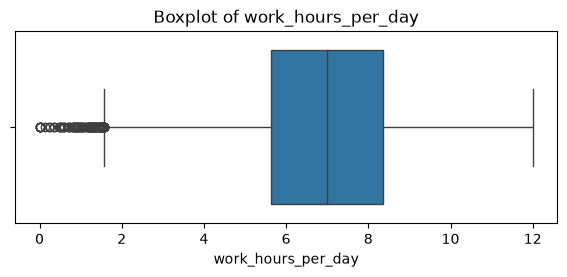

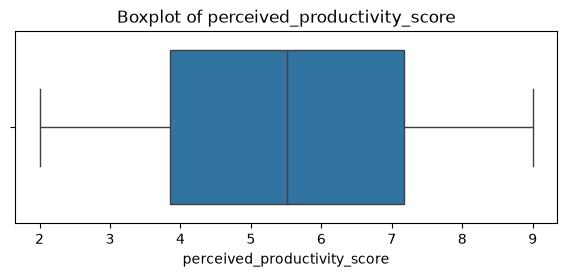

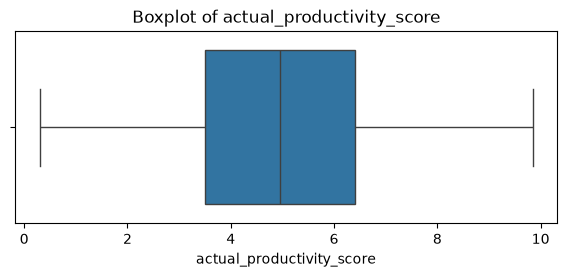

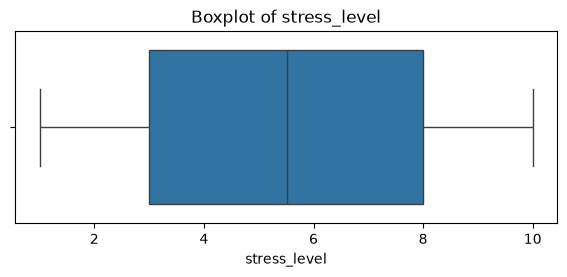

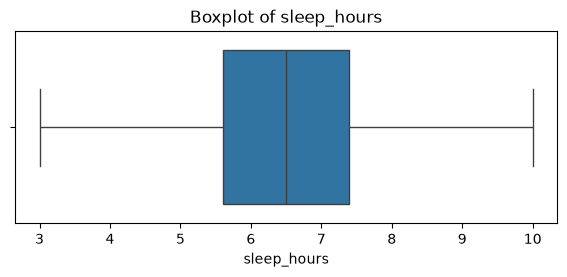

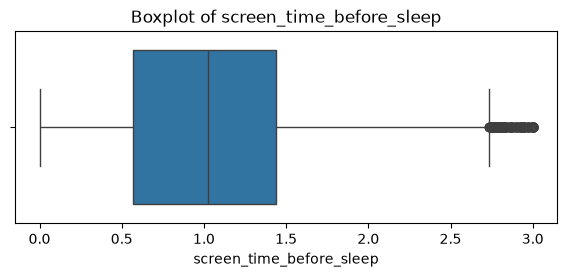

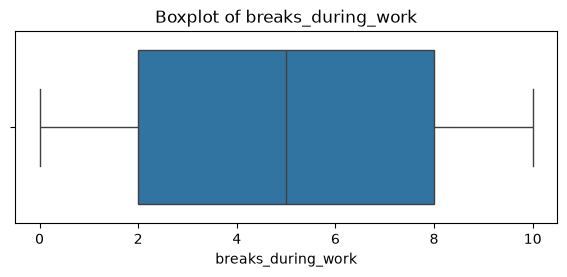

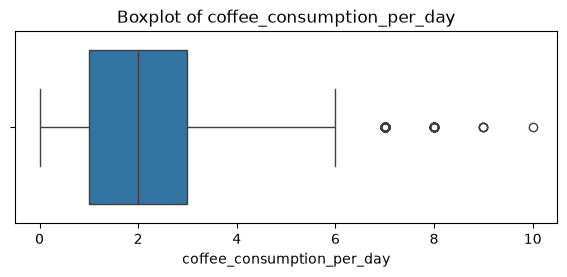

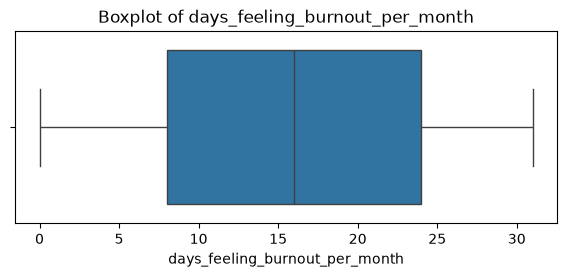

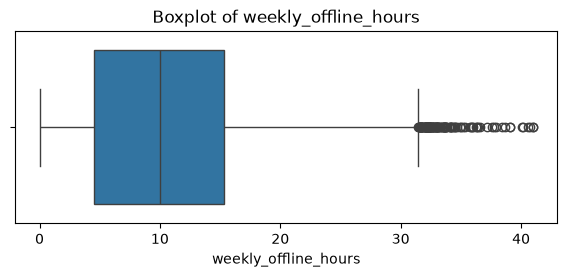

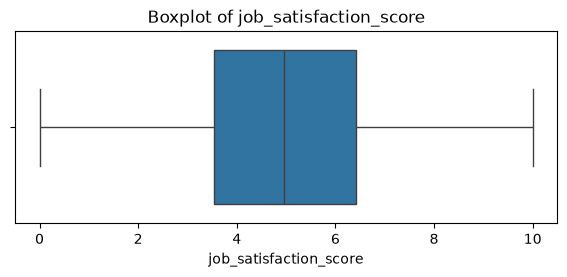

In [8]:
for column in numeric_columns:
    plt.figure(figsize=(7, 2.5))
    sns.boxplot(x=clean_df[column])
    plt.title("Boxplot of " + column)
    plt.show()

## Z-Score Outlier Detection

The Z-score measures how far a value is from the mean in terms of
standard deviations.

Values with an absolute Z-score greater than 3 are considered
potential outliers.

In [9]:
outlier_summary = {}

for column in numeric_columns:
    mean = clean_df[column].mean()
    std = clean_df[column].std()

    z_scores = (clean_df[column] - mean) / std

    outlier_count = (abs(z_scores) > 3).sum()

    outlier_summary[column] = outlier_count

outlier_report = pd.DataFrame(
    list(outlier_summary.items()),
    columns=["Column", "Number of Outliers"]
)

outlier_report

,Column,Number of Outliers
0,age,0
1,daily_social_media_time,180
2,number_of_notifications,84
3,work_hours_per_day,36
4,perceived_productivity_score,0
5,actual_productivity_score,0
6,stress_level,0
7,sleep_hours,0
8,screen_time_before_sleep,93
9,breaks_during_work,0


## Inspecting Extreme Values

Before treating outliers, the minimum and maximum values of numerical
attributes are inspected.

This helps determine whether the detected outliers are invalid values
or meaningful extreme observations.

In [10]:
extreme_values = pd.DataFrame({
    "Minimum": clean_df[numeric_columns].min(),
    "Maximum": clean_df[numeric_columns].max()
})

extreme_values

,Minimum,Maximum
age,18.000000,65.000000
daily_social_media_time,0.000000,17.973256
number_of_notifications,30.000000,90.000000
work_hours_per_day,0.000000,12.000000
perceived_productivity_score,2.000252,8.999376
actual_productivity_score,0.296812,9.846258
stress_level,1.000000,10.000000
sleep_hours,3.000000,10.000000
screen_time_before_sleep,0.000000,3.000000
breaks_during_work,0.000000,10.000000


## Outlier Treatment Decision

The detected outliers were inspected using boxplots, Z-scores and
minimum-maximum values.

The extreme values were found to be possible real-world observations
rather than obvious data-entry errors.

Therefore, the outliers were retained because removing them may remove
important information about users with unusually high digital usage.

No outlier rows were deleted from the dataset.

## Saving the Cleaned Dataset

After handling missing values and inspecting outliers, the cleaned dataset
is saved separately while preserving the original raw dataset.

In [11]:
clean_df.to_csv("Dataset/cleaned_social_media_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Data Quality Report

The condition of the dataset before and after cleaning is compared
to verify the effectiveness of the cleaning process.

In [12]:
quality_report = pd.DataFrame({
    "Metric": [
        "Number of Rows",
        "Number of Columns",
        "Missing Values",
        "Duplicate Rows"
    ],

    "Before Cleaning": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ],

    "After Cleaning": [
        clean_df.shape[0],
        clean_df.shape[1],
        clean_df.isnull().sum().sum(),
        clean_df.duplicated().sum()
    ]
})

quality_report

,Metric,Before Cleaning,After Cleaning
0,Number of Rows,30000,30000
1,Number of Columns,19,19
2,Missing Values,16187,0
3,Duplicate Rows,0,0


## Week 3 Summary

- A separate copy of the raw dataset was created for cleaning.
- Missing values were identified and treated using suitable imputation methods.
- Median imputation was used for the skewed social media usage attribute.
- Mean imputation was used for approximately symmetric numerical attributes.
- Boxplots and Z-scores were used to detect potential outliers.
- Extreme values were inspected before making a treatment decision.
- Valid extreme observations were retained because they may represent meaningful user behaviour.
- A Data Quality Report was generated to compare the dataset before and after cleaning.
- The cleaned dataset was saved separately for Week 4 analysis.